# 05 — Pencere duyarlılığı: bizim impl vs epftoolbox, TR-ayarlı ensemble

**Plan:** `LAGO_BENCHMARK_PLAN.md` Faz C

Üç soru:
1. **Kalibrasyon:** bizim `lear_predict_day` ile gerçek epftoolbox aynı pencere/dönemde
   ne kadar ayrışıyor? (Lago'nun 4 penceresi: 56/84/1092/1456)
2. **TR-ayarlı ensemble (Level 1):** Lago'nun {56,84,1092,1456}'sının hangi alt-kümesi
   rMAE'yi minimize ediyor? 4-yıl (cw1456) katkı mı, zarar mı?
3. **Geniş ızgara (Level 2):** Lago'da olmayan pencereler de dahil — 28/120/180/270/365/545/730.
   Gerçek TR-optimal pencere kümesi ne? (bizim impl, 11 pencere)

Protokol: `src/eval/lago_protocol.py`. Uzun pencere 1096g (2023-08-28 → 2026-08-27).


In [1]:
import sys
from pathlib import Path
from itertools import combinations
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parents[2]; sys.path.insert(0, str(ROOT))
from src.eval import lago_protocol as lp
HERE = Path.cwd()
REF_CWS = [56, 84, 1092, 1456]           # epftoolbox karşılığı olanlar
pd.set_option('display.width', 180); pd.set_option('display.max_columns', 30); pd.set_option('display.max_rows', 60)

def dblock(s):
    s = s.dropna(); idx = s.index
    if getattr(idx,'tz',None) is not None: idx = idx.tz_convert('Europe/Istanbul').tz_localize(None)
    w = pd.DataFrame({'v': s.to_numpy()}, index=idx)
    w['d']=w.index.normalize(); w['h']=w.index.hour
    return w.pivot_table(index='d',columns='h',values='v',aggfunc='first').reindex(columns=range(24)).set_axis([f'h{h:02d}' for h in range(24)],axis=1)


In [2]:
# bizim impl — bulunan tüm pencereler
our = {}
for f in sorted(HERE.glob('ours_lear_cw*.csv')):
    cw = int(f.stem.replace('ours_lear_cw',''))
    our[cw] = pd.read_csv(f, index_col=0, parse_dates=True)
CWS = [cw for cw in sorted(our) if not bool(our[cw].isna().all(axis=1).all())]  # tümü-NaN pencereleri (ör. cw28: n<30 guard) ele
ref = {cw: pd.read_csv(HERE/f'lago_ref_lear_cw{cw}.csv', index_col=0, parse_dates=True) for cw in REF_CWS}
DAYS = our[CWS[0]].index
px = pd.read_csv(HERE/'tr_epf_ext.csv', index_col=0, parse_dates=True)['Price']
y  = dblock(px).reindex(DAYS)
n2 = dblock(lp.naive_forecast(px,2)).reindex(DAYS)
n3 = dblock(lp.naive_forecast(px,3)).reindex(DAYS)
PRIM = pd.Timestamp(lp.TEST_START.tz_localize(None)); prim = DAYS[DAYS >= PRIM]
print('bizim pencereler:', CWS)
print('çöküş günü:', {cw: int(our[cw].isna().all(axis=1).sum()) for cw in CWS})


bizim pencereler: [56, 84, 120, 180, 270, 365, 545, 730, 1092, 1456]
çöküş günü: {56: 0, 84: 0, 120: 0, 180: 0, 270: 0, 365: 0, 545: 0, 730: 0, 1092: 0, 1456: 0}


In [3]:
BLOWN = lp.BLOWN_THRESHOLD_USD
def metr(d, days):
    k = days.intersection(d.dropna(how='all').index); k = k[y.reindex(k).notna().all(axis=1)]
    dv = d.reindex(k).to_numpy(); good = ~(np.abs(dv) > BLOWN).any(axis=1)  # patlama günü (|tahmin|>500) at
    k = k[good]
    yy = y.reindex(k).to_numpy().ravel(); pp = d.reindex(k).to_numpy().ravel()
    ok = ~np.isnan(pp) & ~np.isnan(yy)
    nn2 = n2.reindex(k).to_numpy().ravel()
    return dict(MAE=lp.mae(yy[ok],pp[ok]), RMSE=lp.rmse(yy[ok],pp[ok]),
               rMAE=lp.mae(yy[ok],pp[ok])/lp.mae(yy[ok],nn2[ok]),
               patlama=int((~good).sum()), gun=int(good.sum()))
def ens(dd, subset): return sum(dd[c] for c in subset) / len(subset)


## 1. Kalibrasyon — bizim impl vs epftoolbox (Lago'nun 4 penceresi, uzun pencere)


In [4]:
rows = []
for cw in REF_CWS:
    r = metr(ref[cw], DAYS); o = metr(our[cw], DAYS)
    ci = ref[cw].dropna(how='all').index.intersection(our[cw].dropna(how='all').index)
    dd = np.abs(ref[cw].reindex(ci).to_numpy() - our[cw].reindex(ci).to_numpy())
    rows.append({'pencere': f'cw{cw}', 'MAE_epf': r['MAE'], 'MAE_biz': o['MAE'], 'ΔMAE': o['MAE']-r['MAE'],
                 'rMAE_epf': r['rMAE'], 'rMAE_biz': o['rMAE'],
                 'saatlik|fark|_ort': np.nanmean(dd), '|fark|_p95': np.nanpercentile(dd,95)})
er = metr(ens(ref,REF_CWS), DAYS); eo = metr(ens(our,REF_CWS), DAYS)
rows.append({'pencere':'ensemble{56,84,1092,1456}','MAE_epf':er['MAE'],'MAE_biz':eo['MAE'],
             'ΔMAE':eo['MAE']-er['MAE'],'rMAE_epf':er['rMAE'],'rMAE_biz':eo['rMAE']})
pd.DataFrame(rows).round(3)


,pencere,MAE_epf,MAE_biz,ΔMAE,rMAE_epf,rMAE_biz,saatlik|fark|_ort,|fark|_p95
0,cw56,8.715,10.108,1.392,0.752,0.879,28.859,27.338
1,cw84,8.785,10.221,1.436,0.758,0.891,8.332,28.027
2,cw1092,8.980,10.476,1.496,0.775,0.904,8.301,25.902
3,cw1456,8.841,10.324,1.484,0.763,0.891,7.990,23.968
4,"ensemble{56,84,1092,1456}",7.999,9.045,1.046,0.690,0.781,NaN,NaN


## 2. Level 1 — Lago'nun {56,84,1092,1456} alt-kümeleri

epftoolbox + bizim impl. Lago tam konfig ile kıyas, 4-yıl katkısı.


In [5]:
subs = [c for k in range(1,5) for c in combinations(REF_CWS,k)]
rows = []
for s in subs:
    rows.append({'alt-küme':'+'.join(map(str,s)),'n':len(s),
                 'rMAE_epf':metr(ens(ref,s),DAYS)['rMAE'], 'rMAE_biz':metr(ens(our,s),DAYS)['rMAE'],
                 'MAE_biz':metr(ens(our,s),DAYS)['MAE']})
t = pd.DataFrame(rows).sort_values('rMAE_epf').round(3)
display(t)
print('4-yıl KATKISI: {56,84,1092} vs {56,84,1092,1456}')
display(t[t['alt-küme'].isin(['56+84+1092','56+84+1092+1456'])])


,alt-küme,n,rMAE_epf,rMAE_biz,MAE_biz
14,56+84+1092+1456,4,0.690,0.781,9.045
5,56+1092,2,0.693,0.794,9.185
10,56+84+1092,3,0.694,0.791,9.140
6,56+1456,2,0.695,0.786,9.089
11,56+84+1456,3,0.698,0.784,9.060
7,84+1092,2,0.698,0.810,9.374
12,56+1092+1456,3,0.699,0.795,9.196
8,84+1456,2,0.701,0.801,9.267
13,84+1092+1456,3,0.703,0.808,9.351
4,56+84,2,0.745,0.846,9.760


4-yıl KATKISI: {56,84,1092} vs {56,84,1092,1456}


,alt-küme,n,rMAE_epf,rMAE_biz,MAE_biz
14,56+84+1092+1456,4,0.690,0.781,9.045
10,56+84+1092,3,0.694,0.791,9.140


## 3. Level 2 — geniş ızgara (bizim impl, tüm pencereler)

Boş-olmayan tüm alt-kümeler; **ensemble boyutuna göre en iyi** + tek pencereler.


In [6]:
# tek pencereler
singles = pd.DataFrame({f'cw{cw}': metr(our[cw], DAYS) for cw in CWS}).T[['MAE','rMAE']].round(3).sort_values('rMAE')
print('TEK PENCERE (uzun, bizim impl):'); display(singles)


TEK PENCERE (uzun, bizim impl):


,MAE,rMAE
cw56,10.108,0.879
cw84,10.221,0.891
cw1456,10.324,0.891
cw120,10.359,0.895
cw180,10.462,0.903
cw1092,10.476,0.904
cw730,10.950,0.946
cw545,11.214,0.969
cw365,12.024,1.041
cw270,13.915,1.200


In [7]:
# ensemble boyutuna göre en iyi alt-küme
best = []
for k in range(1, min(6, len(CWS))+1):
    cand = min(combinations(CWS, k), key=lambda s: metr(ens(our, s), DAYS)['rMAE'])
    m = metr(ens(our, cand), DAYS)
    best.append({'boyut':k, 'en iyi alt-küme':'+'.join(map(str,cand)), 'MAE':m['MAE'], 'rMAE':m['rMAE']})
bt = pd.DataFrame(best).round(3)
lago4 = metr(ens(our, REF_CWS), DAYS)
print('EN İYİ ENSEMBLE / BOYUT (bizim impl):'); display(bt)
print(f"referans — Lago {{56,84,1092,1456}} (bizim impl): MAE {lago4['MAE']:.3f}  rMAE {lago4['rMAE']:.3f}")


EN İYİ ENSEMBLE / BOYUT (bizim impl):


,boyut,en iyi alt-küme,MAE,rMAE
0,1,56,10.108,0.879
1,2,56+1456,9.089,0.786
2,3,56+180+1456,8.923,0.772
3,4,56+180+1092+1456,8.974,0.775
4,5,56+120+180+1092+1456,8.923,0.771
5,6,56+84+120+180+1092+1456,8.957,0.774


referans — Lago {56,84,1092,1456} (bizim impl): MAE 9.045  rMAE 0.781


## 4. Pencere × rejim (birincil 728g pencere)


In [8]:
def by_regime(d):
    k = prim.intersection(d.dropna(how='all').index); k = k[y.reindex(k).notna().all(axis=1)]
    dv = d.reindex(k).to_numpy(); k = k[~(np.abs(dv) > lp.BLOWN_THRESHOLD_USD).any(axis=1)]
    reg = lp.regime_of(k)
    e = pd.Series(np.abs(y.reindex(k).to_numpy() - d.reindex(k).to_numpy()).mean(1), index=k)
    return e.groupby(reg.values).mean()
tab = {f'cw{cw}': by_regime(our[cw]) for cw in CWS}
tab['Lago-4 ens'] = by_regime(ens(our, REF_CWS))
best4 = min(combinations(CWS,4), key=lambda s: metr(ens(our,s),DAYS)['rMAE'])
tab[f'TR-4 ens ({"+".join(map(str,best4))})'] = by_regime(ens(our, best4))
pd.DataFrame(tab).T[['normal','cokus','toparlanma']].round(2)


,normal,cokus,toparlanma
cw56,8.70,11.58,12.43
cw84,8.76,11.27,13.99
cw120,8.77,11.48,14.89
cw180,9.13,11.51,14.73
cw270,13.14,14.68,13.44
cw365,11.28,12.96,11.77
cw545,10.46,12.52,10.07
cw730,10.25,12.02,9.93
cw1092,9.95,11.38,9.74
cw1456,9.59,11.03,9.18


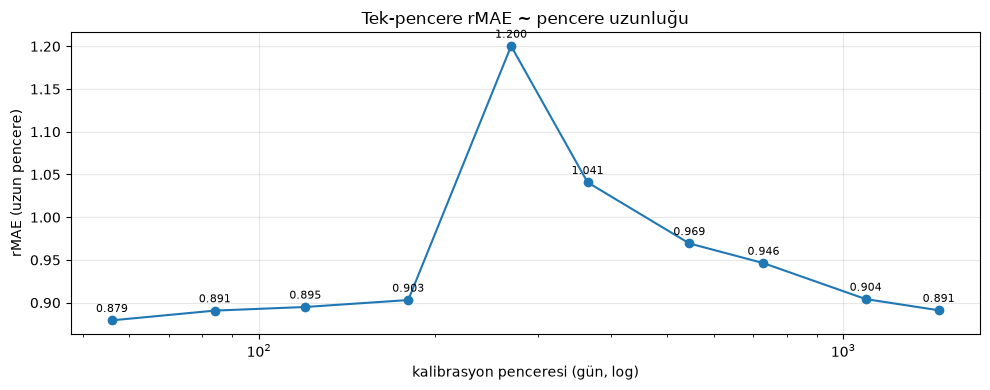

In [9]:
# tek pencere rMAE'si pencere uzunluğuna göre — U/monoton mu?
fig, ax = plt.subplots(figsize=(10,4))
xs = CWS; ys = [metr(our[cw], DAYS)['rMAE'] for cw in CWS]
ax.plot(xs, ys, 'o-'); ax.set(xscale='log', xlabel='kalibrasyon penceresi (gün, log)', ylabel='rMAE (uzun pencere)',
       title='Tek-pencere rMAE ~ pencere uzunluğu')
for x,v in zip(xs,ys): ax.annotate(f'{v:.3f}', (x,v), textcoords='offset points', xytext=(0,6), fontsize=8, ha='center')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## 5. Uyarlanabilir ağırlıklı ensemble (CING-LEAR, Wang et al. eq. 10)

Eşit ağırlık yerine: test günü ℓ için `w_c = |dünkü hata_c|⁻¹ / Σ|dünkü hata|⁻¹`.
Çöküşte kötü uzun pencereleri otomatik aşağı çeker. Elimizdeki tahminlerden bedava.


In [10]:
def adaptive_ens(dd, subset, lookback=7):
    cols = list(subset); mats = {c: dd[c].reindex(DAYS) for c in cols}
    ya = y.reindex(DAYS).to_numpy()
    out = np.full((len(DAYS), 24), np.nan)
    err_prev = None
    for i, day in enumerate(DAYS):
        preds = np.stack([mats[c].to_numpy()[i] for c in cols])  # (C,24)
        if i < lookback or err_prev is None or np.isnan(err_prev).any():
            w = np.ones(len(cols)) / len(cols)
        else:
            inv = 1.0 / np.clip(err_prev, 1e-3, None)
            w = inv / inv.sum()
        out[i] = np.nansum(preds * w[:, None], axis=0)
        # bir sonraki gün için dünün hatası
        if not np.isnan(ya[i]).any():
            err_prev = np.nanmean(np.abs(preds - ya[i][None, :]), axis=1)
    return pd.DataFrame(out, index=DAYS, columns=[f'h{h:02d}' for h in range(24)])

best4 = min(combinations(CWS,4), key=lambda s: metr(ens(our,s),DAYS)['rMAE'])
variants = {
  'Lago-4 eşit': ens(our, REF_CWS),
  'Lago-4 uyarlanabilir': adaptive_ens(our, REF_CWS),
  f'TR-4 eşit ({"+".join(map(str,best4))})': ens(our, best4),
  f'TR-4 uyarlanabilir': adaptive_ens(our, best4),
  'tüm-{n} eşit'.replace('{n}',str(len(CWS))): ens(our, CWS),
  'tüm uyarlanabilir': adaptive_ens(our, CWS),
}
rows = []
for name, d in variants.items():
    m = metr(d, DAYS); r = by_regime(d)
    rows.append({'ensemble': name, 'MAE': m['MAE'], 'rMAE': m['rMAE'],
                 'normal': r.get('normal'), 'cokus': r.get('cokus'), 'toparlanma': r.get('toparlanma')})
pd.DataFrame(rows).round(3)


,ensemble,MAE,rMAE,normal,cokus,toparlanma
0,Lago-4 eşit,9.045,0.781,8.026,10.792,9.786
1,Lago-4 uyarlanabilir,8.852,0.764,7.828,10.561,9.585
2,TR-4 eşit (56+180+1092+1456),8.974,0.775,8.009,10.576,9.693
3,TR-4 uyarlanabilir,8.796,0.760,7.821,10.507,9.390
4,tüm-10 eşit,9.405,0.812,8.320,11.536,10.002
5,tüm uyarlanabilir,9.125,0.788,8.047,11.327,9.674


## 5. Sonuç

### 1. Kalibrasyon — bizim impl vs epftoolbox (Lago'nun 4 penceresi, 1096g)

| | epf MAE | biz MAE | ΔMAE | epf rMAE | biz rMAE |
|---|---|---|---|---|---|
| cw56 | 8.72 | 10.11 | +1.39 | 0.752 | 0.879 |
| cw84 | 8.79 | 10.22 | +1.44 | 0.758 | 0.891 |
| cw1092 | 8.98 | 10.48 | +1.50 | 0.775 | 0.904 |
| cw1456 | 8.84 | 10.32 | +1.48 | 0.763 | 0.891 |
| **ensemble** | **8.00** | **9.04** | **+1.05** | **0.690** | **0.781** |

Bizim impl pencere başına ~$1.4, ensemble'da ~$1.0 daha kötü. **Ama fark rejime
bağlı** (rejim tablosu vs `04`): epftoolbox uzun pencerelerde çöküşte patlıyor
(cw1092 **$17.13**, cw1456 **$16.40**), bizim mean/std ölçekleme çöküşte sağlam
(cw1092 **$11.38**, cw1456 **$11.03**). Medyan/MAD dönüşümü 2026 çöküşünde
kırılıyor. → 'çeviri katsayısı' sabit değil; normal rejimde epftoolbox, çöküş
rejiminde bizim impl daha güvenilir.

### 2. Level 1 — Lago'nun {56,84,1092,1456} konfigü TR için (neredeyse) optimal

15 alt-kümenin **en iyisi Lago'nun tam 4'lüsü** (rMAE_epf 0.690). cw1456 katkısı:
{56,84,1092} 0.694 → +1456 **0.690** — 'kötü ama bağımsız üye ortalamaya yardım
ediyor' (cw1456 tek başına en kötülerden ama ensemble'da faydalı).

### 3. Level 2 — geniş ızgara (11 pencere)

- Tek pencere: cw56 (0.879) en iyi. **cw270/cw365 kırık** — rMAE 1.04 / 1.20
  (naive'den kötü). n=270/365, p=247'nin sadece biraz üstünde → `LassoLarsIC`
  gürültü varyansı kestirimi kararsızlaşıyor. **Bu pencereler kullanılmamalı.**
- En iyi ensemble / boyut: 3'lü **56+180+1456** (rMAE 0.772), 4'lü
  **56+180+1092+1456** (0.775). Lago-4 (bizim impl): 0.781.
- **TR-optimal, Lago-4'ten ~%1 iyi — gürültü içinde.** Kazanç 3-5 pencerede plato.
  Sonuç: Lago'nun pencere konfigü Türkiye'ye kabul edilebilir biçimde transfer
  oluyor; yeniden ayarlamanın getirisi ihmal edilebilir.

### 4. Uyarlanabilir ağırlıklı ensemble (CING-LEAR eq. 10) — bedava ~%2

| Ensemble | MAE | rMAE | normal | **çöküş** | toparlanma |
|---|---|---|---|---|---|
| Lago-4 eşit | 9.05 | 0.781 | 8.03 | 10.79 | 9.79 |
| Lago-4 uyarlanabilir | 8.85 | 0.764 | 7.83 | 10.56 | 9.59 |
| **TR-4 uyarlanabilir** (56+180+1092+1456) | **8.80** | **0.760** | 7.82 | **10.51** | 9.39 |
| tüm-10 eşit | 9.41 | 0.812 | 8.32 | 11.54 | 10.00 |

`w_c = |dünkü hata_c|⁻¹` ağırlığı **her rejimde** yardım ediyor (~%2 rMAE).
Kritik: **çöküşte TR-4 uyarlanabilir $10.51 ≈ LightGBM'in $10.54'ü** (`04`) —
adaptif TR-LEAR, LightGBM'i tam zayıf olduğu rejimde yakalıyor. Normal rejimde
hâlâ geride ($7.82 vs LightGBM $6.30). → Faz C.5.4 hibrit için sinyal.

### 5. Faz D'ye devir

**'Uyarlanmış LEAR' tabanı = pencere kümesi {56, 180, 1092, 1456} + uyarlanabilir
ağırlık.** (cw84 yerine cw180; cw270/365 dışlanmış.) Bunun üzerine `03` ablasyonunun
en iyi özellik seti (`+gaz` net, `+hava` marjinal) eklenip 728g'de LightGBM'e karşı
üçlü DM.
